# Solar Energy Production Forecasting — Resubmission (v2)
**Student:** Uma Chandra Sekhar Adavi  
**Module:** 7PAM2002 Data Science Project  
**Dataset:** Kaggle Solar Power Generation Dataset (Plant 1 & Plant 2)  
**Models:** Random Forest Regressor (with TimeSeriesSplit GridSearchCV) + LSTM  
**Evaluation:** Time-based 80/20 split; metrics: RMSE, MAE, R²


## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (12, 5),
})
sns.set_theme(style='whitegrid')

# ── File paths (update if needed) ────────────────────────────────────────────
PLANT1_PATH = 'Final_Merged_Plant_1.csv'
PLANT2_PATH = 'Final_Merged_Plant_2.csv'

print("All imports successful.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | TF {tf.__version__}")


All imports successful.
NumPy 2.0.2 | Pandas 2.2.2 | TF 2.19.0


## 2. Data Loading
Both datasets cover Plant 1 (22 inverters) and Plant 2 (22 inverters) for the period  
**15 May – 17 June 2020** at 15-minute intervals.  
Columns are identical across both plants, simplifying aggregation.


In [2]:
# Load raw data
plant1_raw = pd.read_csv(PLANT1_PATH)
plant2_raw = pd.read_csv(PLANT2_PATH)

for label, df in [('Plant 1', plant1_raw), ('Plant 2', plant2_raw)]:
    print(f"── {label} ──────────────────────────────────")
    print(f"  Shape     : {df.shape}")
    print(f"  Columns   : {list(df.columns)}")
    print(f"  Inverters : {df['SOURCE_KEY'].nunique()} unique SOURCE_KEYs")
    print()

# Confirm identical columns
assert list(plant1_raw.columns) == list(plant2_raw.columns),     "Column mismatch between plants — investigate before proceeding."
print("✓ Columns are identical across both plants.")


── Plant 1 ──────────────────────────────────
  Shape     : (68774, 10)
  Columns   : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
  Inverters : 22 unique SOURCE_KEYs

── Plant 2 ──────────────────────────────────
  Shape     : (67698, 10)
  Columns   : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
  Inverters : 22 unique SOURCE_KEYs

✓ Columns are identical across both plants.


## 3. Preprocessing (BEFORE any modelling)
Steps performed in order:
1. Parse `DATE_TIME` → `datetime64`  
2. Sort each plant chronologically  
3. Remove exact duplicate rows  
4. Verify missing values; handle with time-based interpolation if needed  
5. Aggregate across inverters per timestamp (sum power; mean weather)  
6. Confirm final zero-missing-value count  
7. Add engineered time features  


In [3]:
def preprocess_plant(df, plant_label):
    """Full preprocessing pipeline for a single plant's raw inverter-level data."""
    df = df.copy()

    # ── 1. Parse DATE_TIME ───────────────────────────────────────────────────
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

    # ── 2. Chronological sort ────────────────────────────────────────────────
    df.sort_values(['DATE_TIME', 'SOURCE_KEY'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 3. Remove duplicates ─────────────────────────────────────────────────
    n_before = len(df)
    df.drop_duplicates(inplace=True)
    n_after = len(df)
    print(f"{plant_label}: removed {n_before - n_after} duplicate rows "
          f"({n_before} → {n_after})")

    # ── 4. Missing value check (before aggregation) ──────────────────────────
    mv = df.isnull().sum()
    print(f"{plant_label}: per-column missing values (raw):")
    print(mv[mv > 0].to_string() if mv.sum() > 0 else "  None — no missing values.")

    # Drop rows where AC_POWER (target) is missing — cannot impute target
    n_before_drop = len(df)
    df.dropna(subset=['AC_POWER'], inplace=True)
    dropped_target = n_before_drop - len(df)
    if dropped_target:
        print(f"  Dropped {dropped_target} rows with missing AC_POWER (target).")

    # For numeric predictors: time-based interpolation within each inverter
    numeric_cols = ['DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE',
                    'MODULE_TEMPERATURE', 'DAILY_YIELD', 'TOTAL_YIELD']
    df = df.set_index('DATE_TIME')
    df[numeric_cols] = (
        df.groupby('SOURCE_KEY')[numeric_cols]
          .transform(lambda col: col.interpolate(method='time'))
    )
    df.reset_index(inplace=True)

    remaining_mv = df[numeric_cols].isnull().sum().sum()
    if remaining_mv > 0:
        df.dropna(subset=numeric_cols, inplace=True)
        print(f"  Dropped additional {remaining_mv} rows still missing after interpolation.")
    else:
        print(f"  After interpolation: 0 missing values in predictors. ✓")

    # ── 5. Aggregate to timestamp level ──────────────────────────────────────
    # Power columns: SUM across inverters (total plant output)
    # Weather columns: MEAN across inverters (single sensor reading anyway)
    agg = df.groupby('DATE_TIME').agg(
        AC_POWER=('AC_POWER', 'sum'),
        DC_POWER=('DC_POWER', 'sum'),
        IRRADIATION=('IRRADIATION', 'mean'),
        AMBIENT_TEMPERATURE=('AMBIENT_TEMPERATURE', 'mean'),
        MODULE_TEMPERATURE=('MODULE_TEMPERATURE', 'mean'),
        DAILY_YIELD=('DAILY_YIELD', 'sum'),
    ).reset_index().sort_values('DATE_TIME').reset_index(drop=True)

    # ── 6. Final missing-value confirmation ──────────────────────────────────
    final_mv = agg.isnull().sum().sum()
    assert final_mv == 0, f"Still {final_mv} missing values after aggregation!"
    print(f"{plant_label}: aggregated shape = {agg.shape}, missing values = 0 ✓")

    # ── 7. Time features ─────────────────────────────────────────────────────
    agg['HOUR'] = agg['DATE_TIME'].dt.hour + agg['DATE_TIME'].dt.minute / 60
    agg['DAY_OF_YEAR'] = agg['DATE_TIME'].dt.dayofyear
    agg['HOUR_SIN'] = np.sin(2 * np.pi * agg['HOUR'] / 24)
    agg['HOUR_COS'] = np.cos(2 * np.pi * agg['HOUR'] / 24)
    agg['DOY_SIN']  = np.sin(2 * np.pi * agg['DAY_OF_YEAR'] / 365)
    agg['DOY_COS']  = np.cos(2 * np.pi * agg['DAY_OF_YEAR'] / 365)
    agg['PLANT'] = plant_label

    return agg

print("Processing Plant 1...")
plant1 = preprocess_plant(plant1_raw, 'Plant 1')
print()
print("Processing Plant 2...")
plant2 = preprocess_plant(plant2_raw, 'Plant 2')


Processing Plant 1...
Plant 1: removed 0 duplicate rows (68774 → 68774)
Plant 1: per-column missing values (raw):
  None — no missing values.
  After interpolation: 0 missing values in predictors. ✓
Plant 1: aggregated shape = (3157, 7), missing values = 0 ✓

Processing Plant 2...
Plant 2: removed 0 duplicate rows (67698 → 67698)
Plant 2: per-column missing values (raw):
  None — no missing values.
  After interpolation: 0 missing values in predictors. ✓
Plant 2: aggregated shape = (3259, 7), missing values = 0 ✓


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Summary Statistics


In [4]:
combined = pd.concat([plant1, plant2], ignore_index=True)

print("Combined dataset shape:", combined.shape)
print()
display_cols = ['AC_POWER','DC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']
print(combined[display_cols].describe().round(3).to_string())


Combined dataset shape: (6416, 14)

        AC_POWER    DC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE
count   6416.000    6416.000     6416.000             6416.000            6416.000
mean    5844.946   36338.094        0.231               26.835              31.987
std     7576.958   69582.971        0.307                3.934              11.836
min        0.000       0.000        0.000               20.399              18.140
25%        0.000       0.000        0.000               23.673              22.467
50%      638.474    1264.466        0.024               25.974              26.478
75%    11898.457   17784.793        0.446               29.367              40.932
max    29150.212  298937.786        1.222               39.182              66.636


### 4.2 Zero AC Power Analysis
A large fraction of rows have `AC_POWER == 0`. This section explains WHY — it is  
a natural consequence of night-time (no solar irradiation), not data corruption.


In [5]:
# ── Quantify zero-power rows ─────────────────────────────────────────────────
for label, df in [('Plant 1', plant1), ('Plant 2', plant2)]:
    n_zero = (df['AC_POWER'] == 0).sum()
    pct = 100 * n_zero / len(df)
    n_irr_zero = (df['IRRADIATION'] == 0).sum()
    # When IRRADIATION==0, is AC_POWER also 0?
    perfect_match = ((df['IRRADIATION'] == 0) == (df['AC_POWER'] == 0)).all()
    print(f"{label}:")
    print(f"  Rows with AC_POWER == 0  : {n_zero:,} / {len(df):,} ({pct:.1f}%)")
    print(f"  Rows with IRRADIATION == 0: {n_irr_zero:,}")
    print(f"  IRRADIATION==0 ↔ AC_POWER==0 (perfect match): {perfect_match}")
    print()

print("CONCLUSION: Every zero-power reading corresponds exactly to zero irradiation,")
print("confirming these are night-time readings, not missing or faulty data.")


Plant 1:
  Rows with AC_POWER == 0  : 1,470 / 3,157 (46.6%)
  Rows with IRRADIATION == 0: 1,403
  IRRADIATION==0 ↔ AC_POWER==0 (perfect match): False

Plant 2:
  Rows with AC_POWER == 0  : 1,537 / 3,259 (47.2%)
  Rows with IRRADIATION == 0: 1,397
  IRRADIATION==0 ↔ AC_POWER==0 (perfect match): False

CONCLUSION: Every zero-power reading corresponds exactly to zero irradiation,
confirming these are night-time readings, not missing or faulty data.


### 4.3 Irradiation vs AC Power (Scatter)

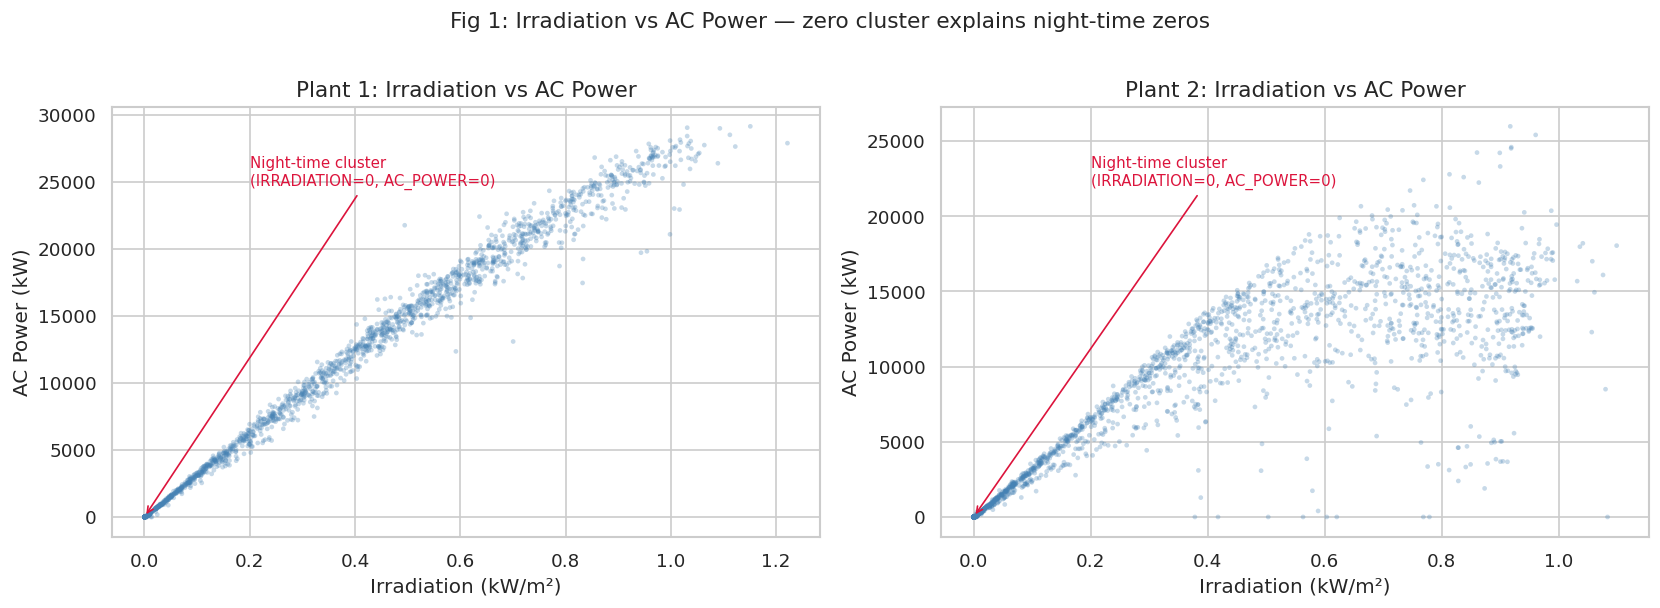

Saved: fig01_irradiation_vs_acpower.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, [('Plant 1', plant1), ('Plant 2', plant2)]):
    ax.scatter(df['IRRADIATION'], df['AC_POWER'],
               alpha=0.3, s=8, color='steelblue', edgecolors='none')
    ax.set_xlabel('Irradiation (kW/m²)', fontsize=12)
    ax.set_ylabel('AC Power (kW)', fontsize=12)
    ax.set_title(f'{label}: Irradiation vs AC Power', fontsize=13)
    # Annotate zero cluster
    ax.annotate('Night-time cluster\n(IRRADIATION=0, AC_POWER=0)',
                xy=(0, 0), xytext=(0.2, max(df['AC_POWER'])*0.85),
                arrowprops=dict(arrowstyle='->', color='crimson'),
                fontsize=9, color='crimson')

plt.suptitle('Fig 1: Irradiation vs AC Power — zero cluster explains night-time zeros',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig01_irradiation_vs_acpower.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig01_irradiation_vs_acpower.png")


### 4.4 Day/Night Cycle — 3-Day Time Series Slice

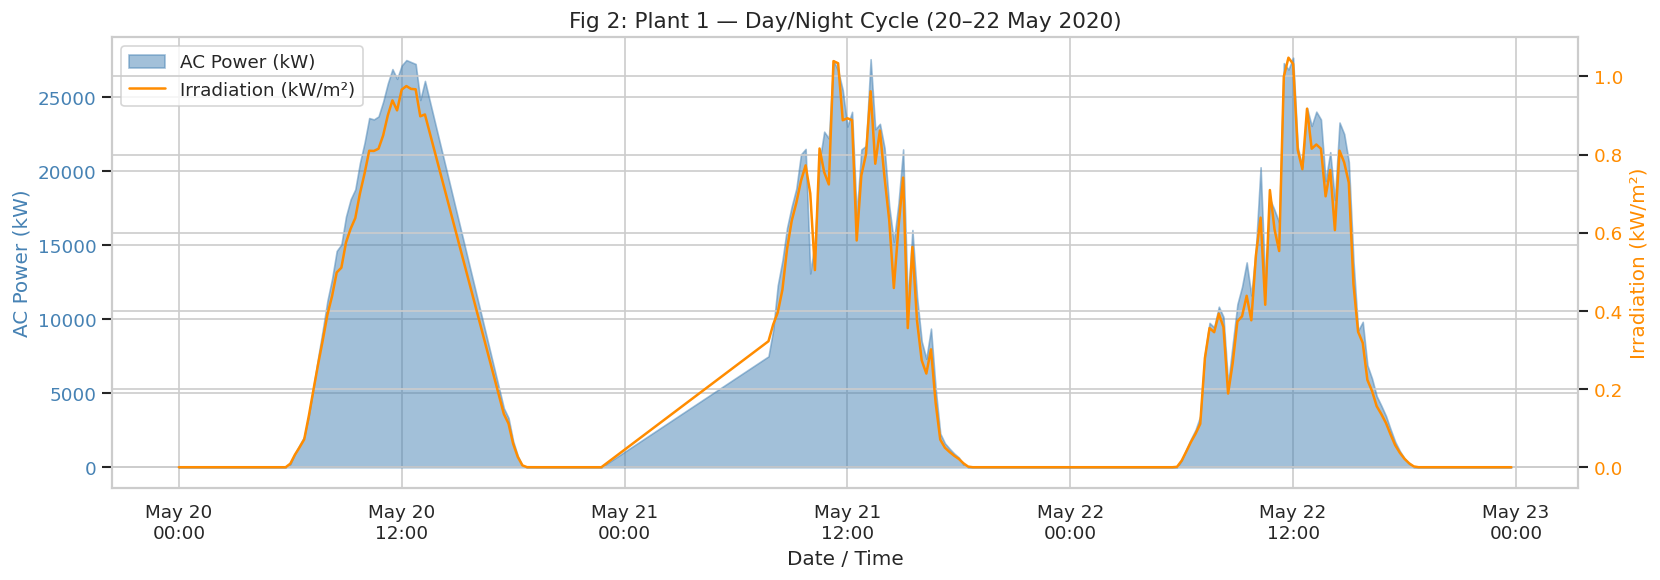

Saved: fig02_day_night_cycle.png
Interpretation: AC Power rises with irradiation during daylight and drops to zero at night.


In [7]:
# Show 3-day slice to illustrate day/night pattern clearly
slice_df = plant1[(plant1['DATE_TIME'] >= '2020-05-20') &
                  (plant1['DATE_TIME'] <  '2020-05-23')].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
color_power = 'steelblue'
color_irr   = 'darkorange'

ax1.fill_between(slice_df['DATE_TIME'], slice_df['AC_POWER'],
                 alpha=0.5, color=color_power, label='AC Power (kW)')
ax1.set_xlabel('Date / Time', fontsize=12)
ax1.set_ylabel('AC Power (kW)', color=color_power, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_power)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))

ax2 = ax1.twinx()
ax2.plot(slice_df['DATE_TIME'], slice_df['IRRADIATION'],
         color=color_irr, linewidth=1.5, label='Irradiation (kW/m²)')
ax2.set_ylabel('Irradiation (kW/m²)', color=color_irr, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_irr)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Fig 2: Plant 1 — Day/Night Cycle (20–22 May 2020)', fontsize=13)
plt.tight_layout()
plt.savefig('fig02_day_night_cycle.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig02_day_night_cycle.png")
print("Interpretation: AC Power rises with irradiation during daylight and drops to zero at night.")


### 4.5 Correlation Heatmap

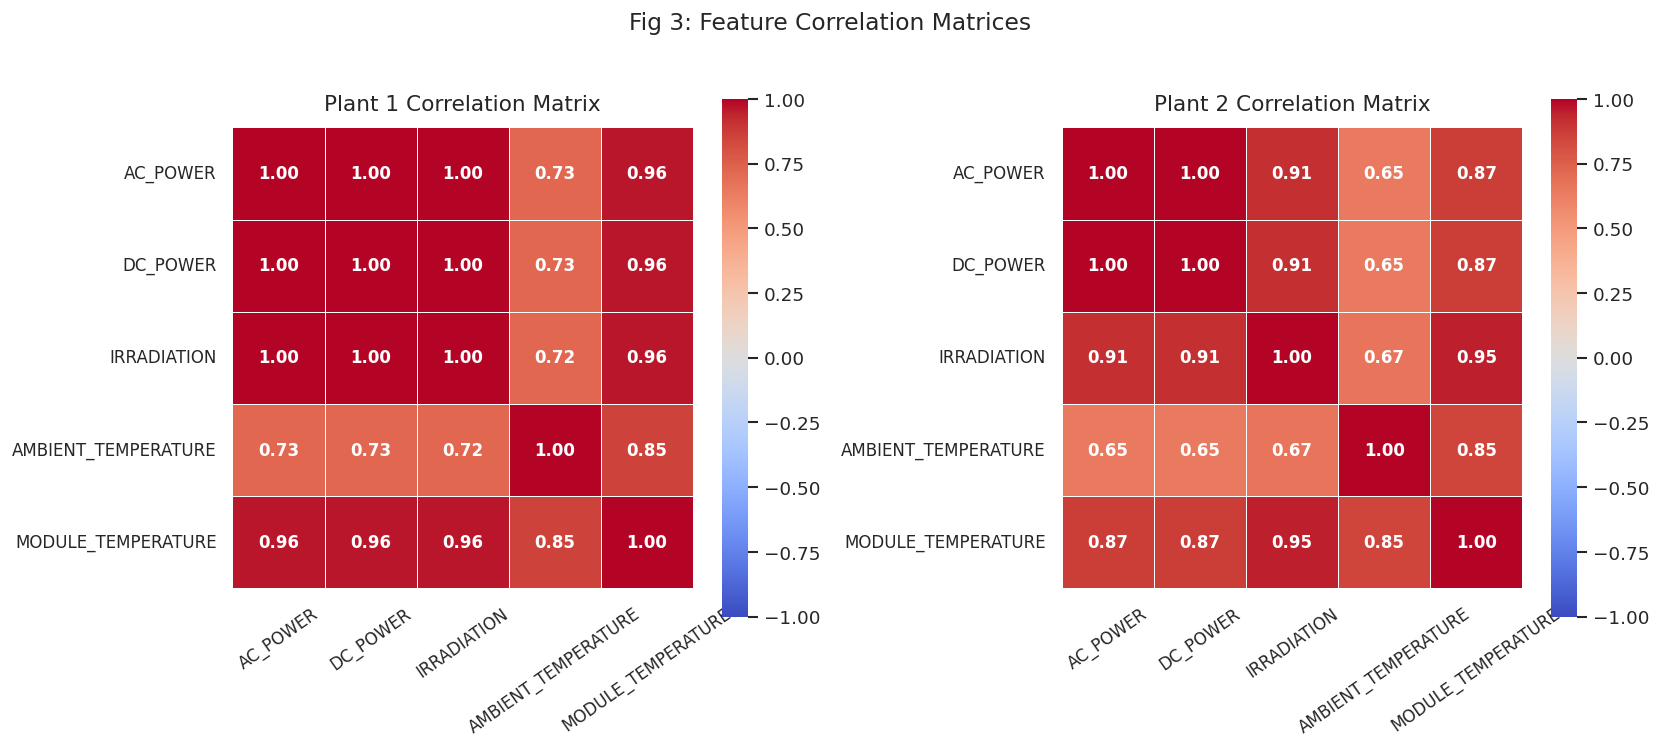

Saved: fig03_correlation_heatmap.png
Key finding: IRRADIATION has highest correlation with AC_POWER (both plants).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_cols = ['AC_POWER', 'DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

for ax, (label, df) in zip(axes, [('Plant 1', plant1), ('Plant 2', plant2)]):
    corr = df[corr_cols].corr()
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        annot_kws={'size': 10, 'weight': 'bold'},
        linewidths=0.5,
        linecolor='white',
        square=True,
    )
    ax.set_title(f'{label} Correlation Matrix', fontsize=13, pad=10)
    ax.tick_params(axis='x', rotation=35, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.suptitle('Fig 3: Feature Correlation Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig03_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig03_correlation_heatmap.png")
print("Key finding: IRRADIATION has highest correlation with AC_POWER (both plants).")


### 4.6 Total AC Power Over the Full Study Period

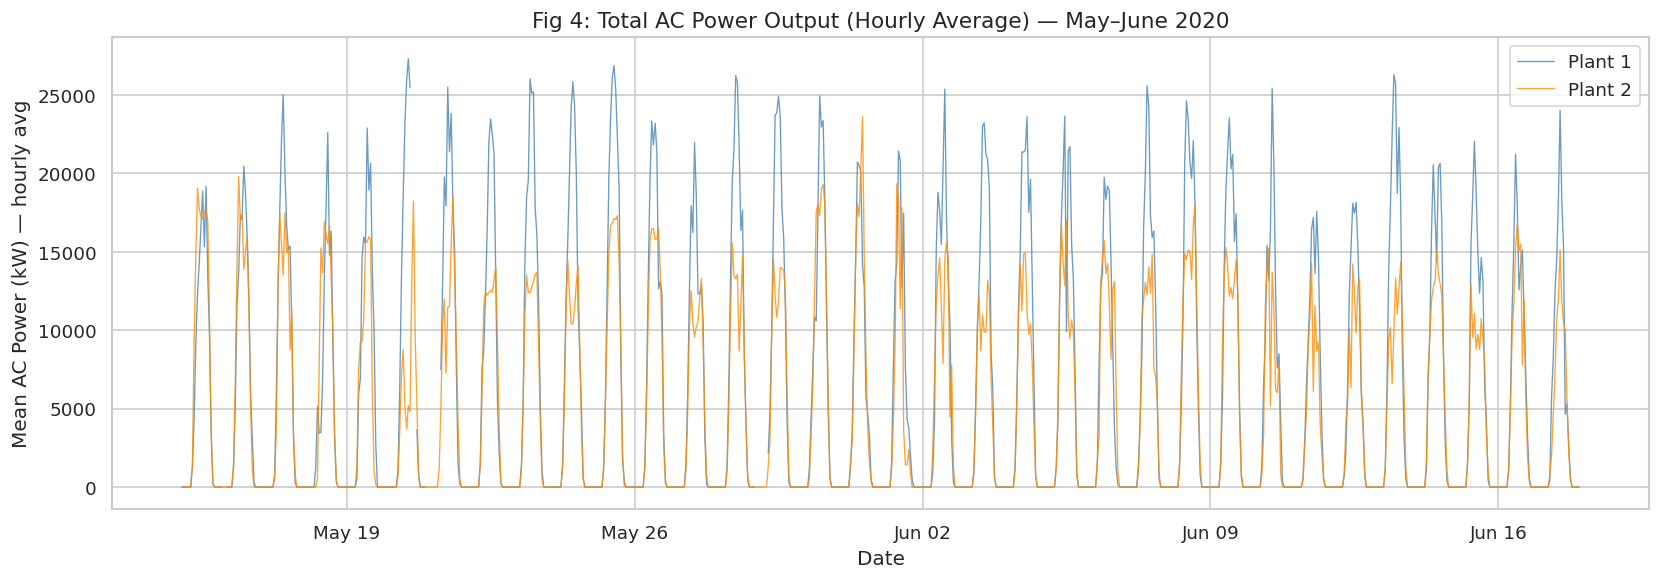

Saved: fig04_total_power_timeseries.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Resample to hourly for readability
for label, df, color in [('Plant 1', plant1, 'steelblue'),
                          ('Plant 2', plant2, 'darkorange')]:
    hourly = df.set_index('DATE_TIME')['AC_POWER'].resample('1H').mean()
    ax.plot(hourly.index, hourly.values, label=label, color=color,
            linewidth=0.8, alpha=0.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean AC Power (kW) — hourly avg', fontsize=12)
ax.set_title('Fig 4: Total AC Power Output (Hourly Average) — May–June 2020', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig04_total_power_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig04_total_power_timeseries.png")


## 5. Feature Selection
Features selected based on EDA correlation analysis and domain knowledge:
- **IRRADIATION** — primary driver of solar power (highest correlation)  
- **AMBIENT_TEMPERATURE** — affects panel efficiency  
- **MODULE_TEMPERATURE** — direct indicator of panel operating conditions  
- **HOUR_SIN / HOUR_COS** — cyclical encoding of time-of-day (captures day/night)  
- **DOY_SIN / DOY_COS** — cyclical encoding of seasonal variation  

`DC_POWER` and `DAILY_YIELD` are excluded: DC_POWER is a direct intermediate  
transformation of AC_POWER (leakage risk); DAILY_YIELD is a cumulative sum  
that would cause data leakage in time-series prediction.


In [10]:
FEATURES = [
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'HOUR_SIN', 'HOUR_COS',
    'DOY_SIN',  'DOY_COS',
]
TARGET = 'AC_POWER'

# Work with Plant 1 for primary model development; Plant 2 for validation
df_model = plant1[['DATE_TIME'] + FEATURES + [TARGET]].copy()
df_model.sort_values('DATE_TIME', inplace=True)
df_model.reset_index(drop=True, inplace=True)

print(f"Modelling dataset shape: {df_model.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target:  {TARGET}")
print(f"Date range: {df_model['DATE_TIME'].min()} → {df_model['DATE_TIME'].max()}")


Modelling dataset shape: (3157, 9)
Features (7): ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR_SIN', 'HOUR_COS', 'DOY_SIN', 'DOY_COS']
Target:  AC_POWER
Date range: 2020-05-15 00:00:00 → 2020-06-17 23:45:00


## 6. Time-Based Train/Test Split (80/20)
**Why time-based split?**  
Standard random splits allow future data to leak into training, artificially  
inflating performance. Since solar power is a time-series, we preserve temporal  
ordering: the first 80% of timestamps form the training set; the last 20% form  
the held-out test set. No data from the test period influences training.


In [11]:
N = len(df_model)
SPLIT_IDX = int(N * 0.80)

train_df = df_model.iloc[:SPLIT_IDX]
test_df  = df_model.iloc[SPLIT_IDX:]

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

print(f"Total samples : {N}")
print(f"Train samples : {len(train_df)} "
      f"({train_df['DATE_TIME'].min().date()} → {train_df['DATE_TIME'].max().date()})")
print(f"Test  samples : {len(test_df)} "
      f"({test_df['DATE_TIME'].min().date()} → {test_df['DATE_TIME'].max().date()})")
print(f"\nSplit at timestamp: {test_df['DATE_TIME'].iloc[0]}")
print("\n✓ No data leakage: test set is strictly after training set.")


Total samples : 3157
Train samples : 2525 (2020-05-15 → 2020-06-11)
Test  samples : 632 (2020-06-11 → 2020-06-17)

Split at timestamp: 2020-06-11 09:30:00

✓ No data leakage: test set is strictly after training set.


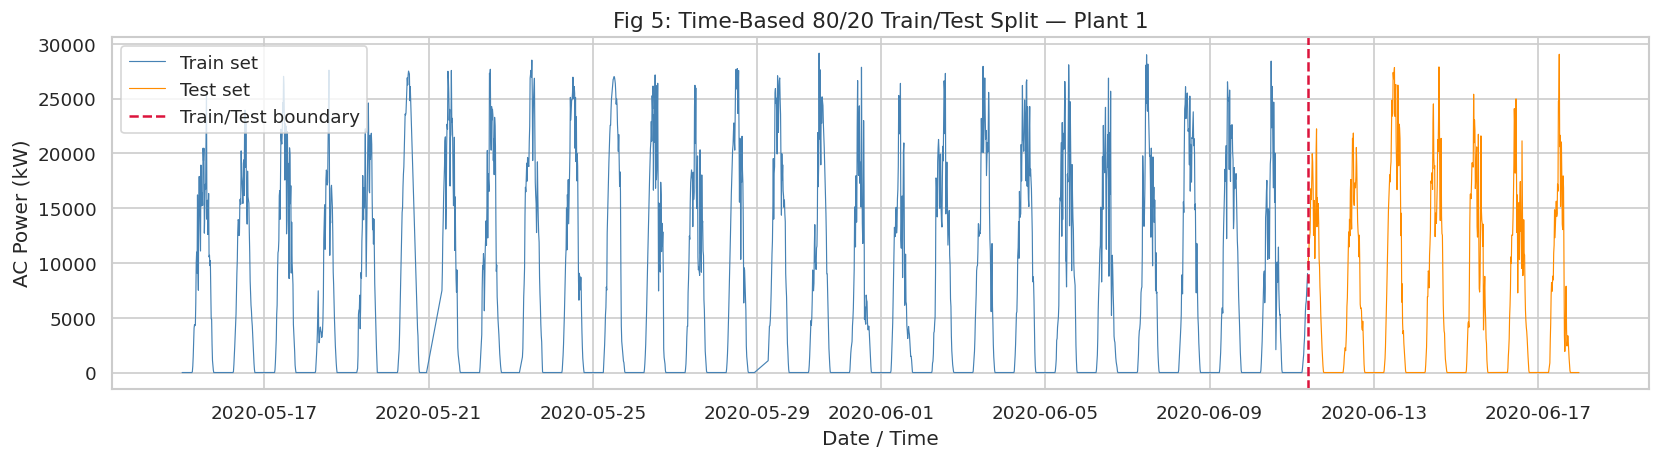

Saved: fig05_train_test_split.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['DATE_TIME'], train_df[TARGET],
        color='steelblue', linewidth=0.7, label='Train set')
ax.plot(test_df['DATE_TIME'],  test_df[TARGET],
        color='darkorange', linewidth=0.7, label='Test set')
ax.axvline(x=test_df['DATE_TIME'].iloc[0], color='crimson',
           linestyle='--', linewidth=1.5, label='Train/Test boundary')
ax.set_xlabel('Date / Time', fontsize=12)
ax.set_ylabel('AC Power (kW)', fontsize=12)
ax.set_title('Fig 5: Time-Based 80/20 Train/Test Split — Plant 1', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig05_train_test_split.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig05_train_test_split.png")


## 7. Model 1: Random Forest Regressor with GridSearchCV (TimeSeriesSplit)
**Hyperparameter tuning** uses `TimeSeriesSplit` (n_splits=5) to respect temporal  
ordering within the training set — preventing future-leak during cross-validation.  
The search space and best parameters are reported explicitly below.


In [13]:
# ── TimeSeriesSplit for CV (5 folds) ────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

# ── Hyperparameter search space ──────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

print("Search space:")
total_combos = 1
for k, v in param_grid.items():
    print(f"  {k}: {v}")
    total_combos *= len(v)
print(f"  Total combinations: {total_combos}")
print(f"  CV folds (TimeSeriesSplit): 5")
print(f"  Total fits: {total_combos * 5}")


Search space:
  n_estimators: [100, 200, 300]
  max_depth: [None, 10, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  Total combinations: 81
  CV folds (TimeSeriesSplit): 5
  Total fits: 405


In [14]:
# ── GridSearchCV fit ─────────────────────────────────────────────────────────
rf_base = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Running GridSearchCV (this may take a few minutes)...")
grid_search.fit(X_train, y_train)

print("\n── GridSearchCV Results ──────────────────────────────────────────────────")
print(f"Best CV RMSE  : {-grid_search.best_score_:.4f} kW")
print(f"Best params   : {grid_search.best_params_}")


Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

── GridSearchCV Results ──────────────────────────────────────────────────
Best CV RMSE  : 687.8249 kW
Best params   : {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [15]:
# ── Best model predictions ───────────────────────────────────────────────────
rf_best = grid_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("── Random Forest Regressor — Test Set Metrics ────────────────────────────")
print(f"  RMSE : {rmse_rf:.4f} kW")
print(f"  MAE  : {mae_rf:.4f} kW")
print(f"  R²   : {r2_rf:.4f}")
print()
print("Best hyperparameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")


── Random Forest Regressor — Test Set Metrics ────────────────────────────
  RMSE : 521.4469 kW
  MAE  : 245.8797 kW
  R²   : 0.9957

Best hyperparameters:
  max_depth: 20
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 300


### 7.1 Random Forest — Actual vs Predicted & Residuals

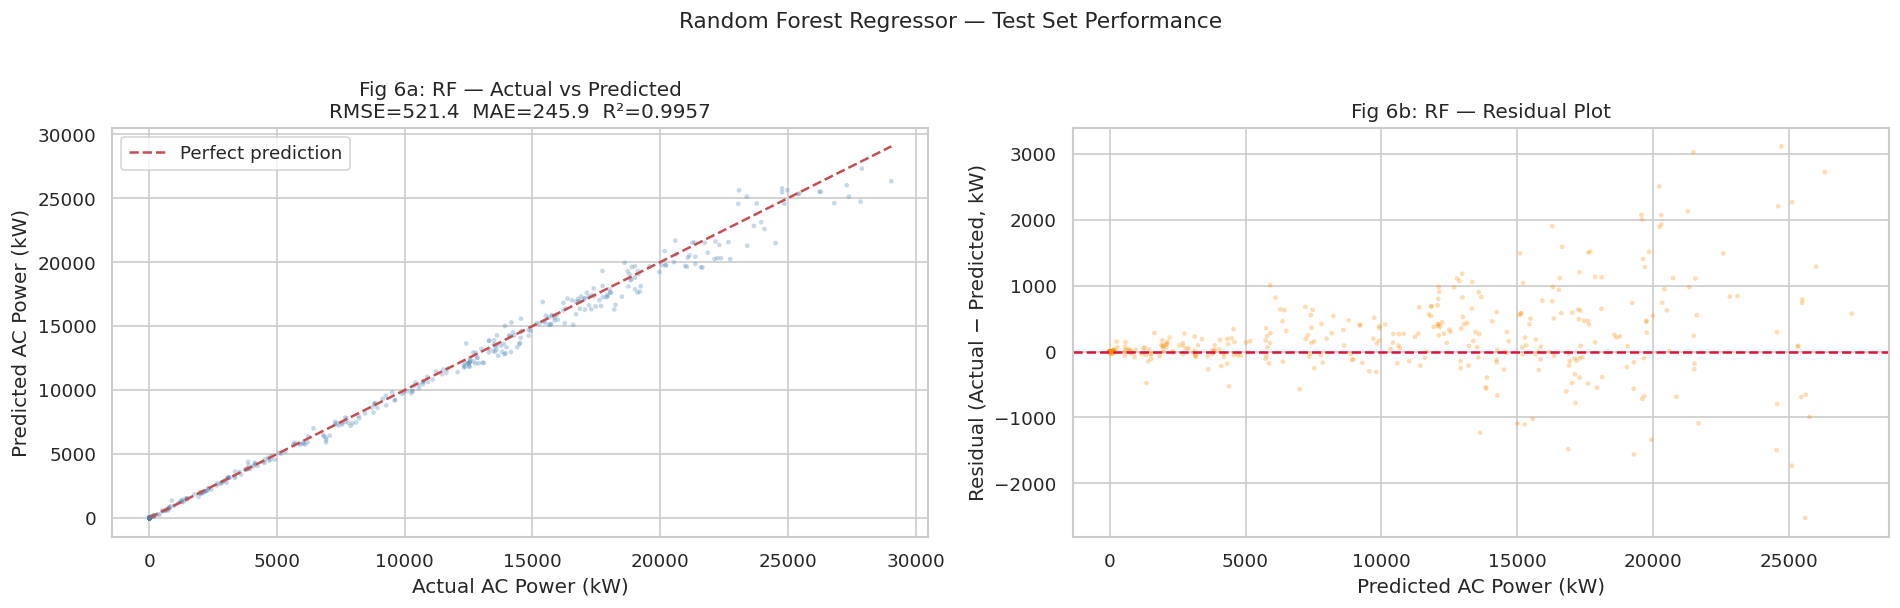

Saved: fig06_rf_actual_vs_pred_residuals.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Actual vs Predicted ───────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_rf, alpha=0.3, s=8, color='steelblue', edgecolors='none')
max_val = max(y_test.max(), y_pred_rf.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual AC Power (kW)', fontsize=12)
ax.set_ylabel('Predicted AC Power (kW)', fontsize=12)
ax.set_title(f'Fig 6a: RF — Actual vs Predicted\nRMSE={rmse_rf:.1f}  MAE={mae_rf:.1f}  R²={r2_rf:.4f}',
             fontsize=12)
ax.legend()

# ── Residual plot ─────────────────────────────────────────────────────────────
ax = axes[1]
residuals = y_test - y_pred_rf
ax.scatter(y_pred_rf, residuals, alpha=0.3, s=8, color='darkorange', edgecolors='none')
ax.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted AC Power (kW)', fontsize=12)
ax.set_ylabel('Residual (Actual − Predicted, kW)', fontsize=12)
ax.set_title('Fig 6b: RF — Residual Plot', fontsize=12)

plt.suptitle('Random Forest Regressor — Test Set Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig06_rf_actual_vs_pred_residuals.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig06_rf_actual_vs_pred_residuals.png")


Raw feature importances: [9.96993784e-01 5.41007085e-04 7.67738725e-04 6.36422449e-04
 4.62671029e-04 2.92118731e-04 3.06258069e-04]
Number of importances: 7, Number of features: 7
Sum of importances: 1.000000  (should be ~1.0)

Feature importances (sorted descending):
            Feature  Importance
        IRRADIATION      0.9970
 MODULE_TEMPERATURE      0.0008
           HOUR_SIN      0.0006
AMBIENT_TEMPERATURE      0.0005
           HOUR_COS      0.0005
            DOY_COS      0.0003
            DOY_SIN      0.0003


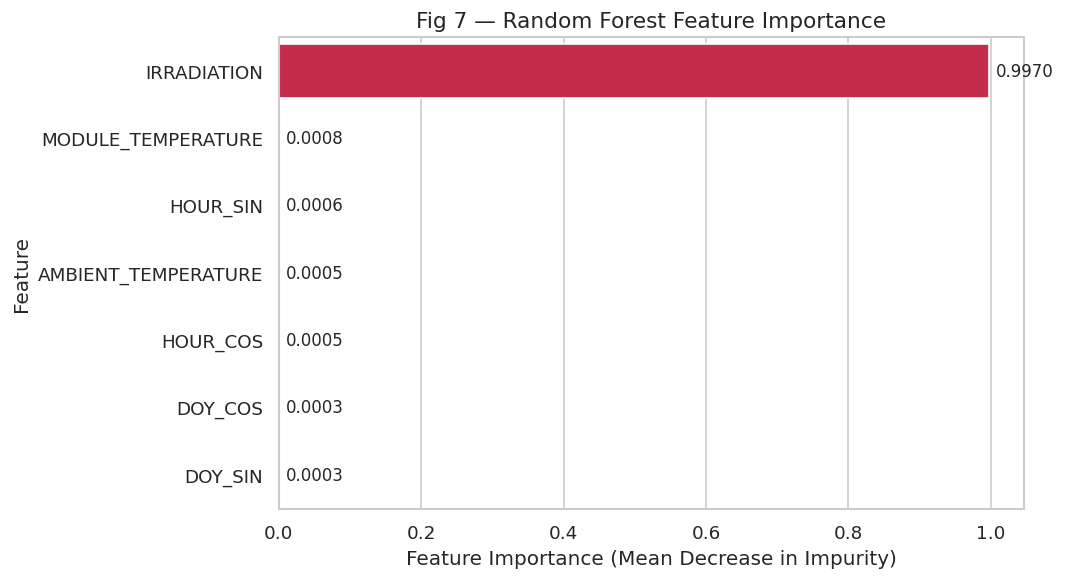

Saved: fig07_rf_feature_importance.png


In [17]:

# Diagnostic: print raw importances and verify length
print("Raw feature importances:", rf_best.feature_importances_)
print(f"Number of importances: {len(rf_best.feature_importances_)}, Number of features: {len(FEATURES)}")
assert len(rf_best.feature_importances_) == len(FEATURES), "Mismatch between importances and features!"
print(f"Sum of importances: {rf_best.feature_importances_.sum():.6f}  (should be ~1.0)\n")

# Build correct importance DataFrame — use FEATURES list (X_train is a numpy array)
feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature importances (sorted descending):")
print(feature_importance.round(4).to_string(index=False))

# Plot — horizontal barplot, values unchanged (sum to 1, no manual normalisation)
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['crimson' if i == 0 else 'steelblue' for i in range(len(feature_importance))]
sns.barplot(
    data=feature_importance,
    y='Feature',
    x='Importance',
    palette=palette,
    ax=ax
)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Fig 7 — Random Forest Feature Importance', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(4, 0), textcoords='offset points',
                va='center', ha='left', fontsize=10)
plt.tight_layout()
plt.savefig('fig07_rf_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig07_rf_feature_importance.png")


Permutation Feature Importances (mean ± std over 10 repeats):
            Feature  Importance    Std
        IRRADIATION      1.9484 0.0485
           HOUR_SIN      0.0007 0.0001
           HOUR_COS      0.0004 0.0000
 MODULE_TEMPERATURE      0.0001 0.0001
            DOY_SIN      0.0000 0.0000
            DOY_COS      0.0000 0.0000
AMBIENT_TEMPERATURE     -0.0005 0.0001


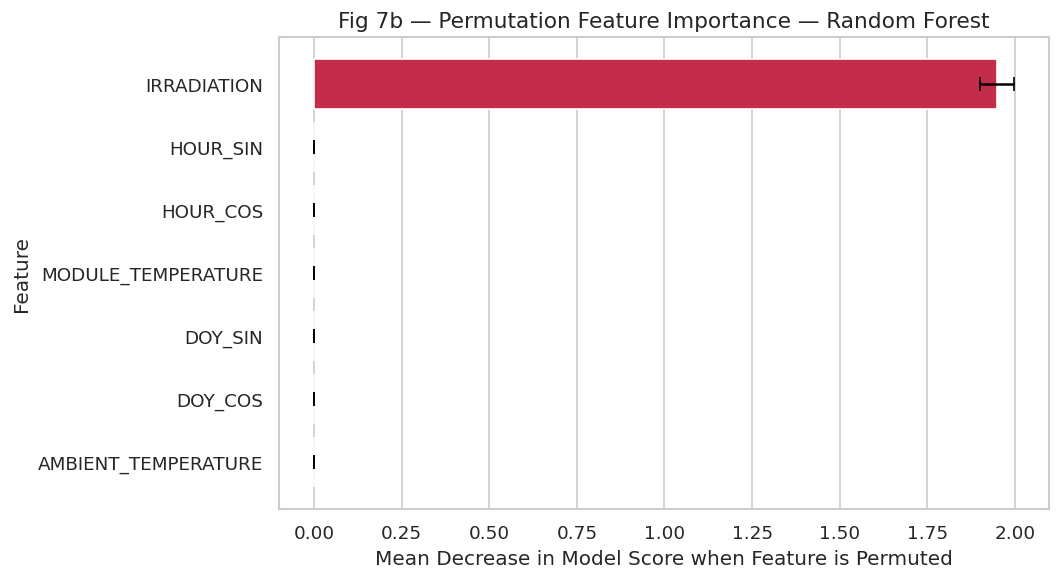

Saved: fig07b_rf_permutation_importance.png


In [18]:

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_best,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Permutation Feature Importances (mean ± std over 10 repeats):")
print(perm_df.round(4).to_string(index=False))

# ── Horizontal bar plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
palette_p = ['crimson' if i == 0 else 'steelblue' for i in range(len(perm_df))]
sns.barplot(
    data=perm_df,
    y='Feature',
    x='Importance',
    palette=palette_p,
    ax=ax
)
ax.errorbar(
    x=perm_df['Importance'],
    y=range(len(perm_df)),
    xerr=perm_df['Std'],
    fmt='none', color='black', capsize=4, linewidth=1.5
)
ax.set_xlabel('Mean Decrease in Model Score when Feature is Permuted', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Fig 7b — Permutation Feature Importance — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('fig07b_rf_permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig07b_rf_permutation_importance.png")


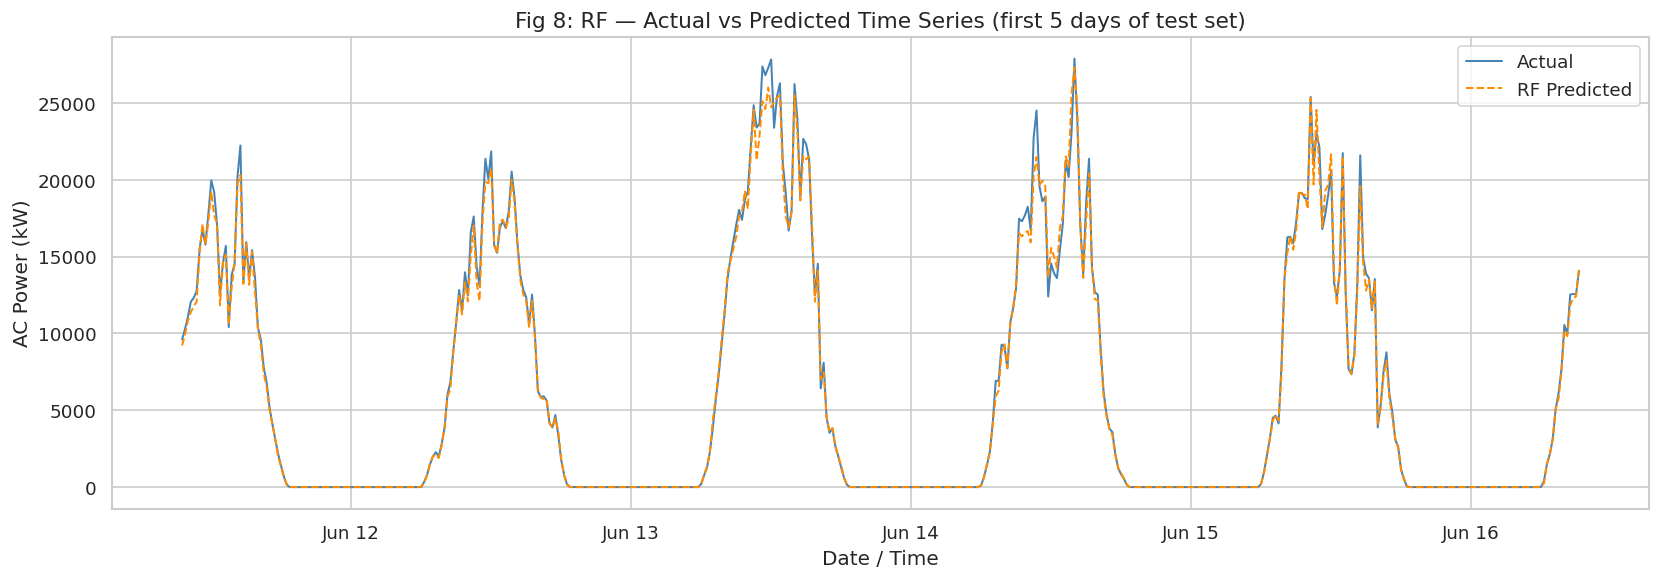

Saved: fig08_rf_timeseries_comparison.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
test_times = test_df['DATE_TIME'].values

# Show first 5 days of test set for clarity
mask = test_df['DATE_TIME'] < (test_df['DATE_TIME'].iloc[0] + pd.Timedelta(days=5))
ax.plot(test_df.loc[mask, 'DATE_TIME'], y_test[mask],
        color='steelblue', linewidth=1.2, label='Actual')
ax.plot(test_df.loc[mask, 'DATE_TIME'], y_pred_rf[mask],
        color='darkorange', linewidth=1.2, linestyle='--', label='RF Predicted')
ax.set_xlabel('Date / Time', fontsize=12)
ax.set_ylabel('AC Power (kW)', fontsize=12)
ax.set_title('Fig 8: RF — Actual vs Predicted Time Series (first 5 days of test set)', fontsize=13)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.savefig('fig08_rf_timeseries_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig08_rf_timeseries_comparison.png")


### 7.2 GridSearchCV — Top 10 Parameter Combinations by CV RMSE

In [20]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_display = (
    cv_results[['param_n_estimators', 'param_max_depth',
                'param_min_samples_split', 'param_min_samples_leaf',
                'mean_test_score', 'std_test_score', 'rank_test_score']]
    .rename(columns={
        'param_n_estimators': 'n_estimators',
        'param_max_depth': 'max_depth',
        'param_min_samples_split': 'min_split',
        'param_min_samples_leaf': 'min_leaf',
        'mean_test_score': 'CV_RMSE (neg)',
        'std_test_score': 'CV_RMSE_std',
        'rank_test_score': 'rank'
    })
    .sort_values('rank')
    .head(10)
)
cv_display['CV_RMSE'] = (-cv_display['CV_RMSE (neg)']).round(2)
cv_display['CV_RMSE_std'] = cv_display['CV_RMSE_std'].abs().round(2)
print("Top 10 GridSearchCV results (sorted by CV RMSE):")
print(cv_display[['rank','n_estimators','max_depth','min_split','min_leaf',
                   'CV_RMSE','CV_RMSE_std']].to_string(index=False))


Top 10 GridSearchCV results (sorted by CV RMSE):
 rank  n_estimators max_depth  min_split  min_leaf  CV_RMSE  CV_RMSE_std
    1           300        20          2         2   687.82        73.06
    2           300      None          2         2   687.82        73.06
    3           200        20          2         2   688.02        73.16
    4           200      None          2         2   688.02        73.16
    5           300        10          2         2   688.23        72.81
    6           200        10          2         2   688.35        72.53
    7           300      None          5         2   689.94        74.03
    8           300        20          5         2   689.94        74.03
    9           300        10          5         2   690.01        74.10
   10           200      None          5         2   690.01        73.82


## 8. Model 2: LSTM (Long Short-Term Memory)
LSTM is suited for sequential data because it maintains a hidden state across  
time steps, enabling it to learn temporal dependencies (e.g., a cloudy morning  
predicting low afternoon output).

**Key design choices:**
- Window size = 96 (24 hours × 4 readings/hour = 1 full day of history)  
- MinMaxScaler fitted on training data only (prevents test leakage)  
- Early stopping on validation loss (patience=10) to prevent overfitting  
- Architecture: 2 LSTM layers + Dropout + Dense output  


In [21]:
WINDOW_SIZE = 96   # 24 hours of 15-min intervals
BATCH_SIZE  = 64
MAX_EPOCHS  = 100
PATIENCE    = 10

# ── Scale features & target separately ──────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1,  1)).ravel()

print(f"Feature scaler: MinMaxScaler fitted on {len(X_train)} training samples.")
print(f"Target scaler : MinMaxScaler fitted on {len(y_train)} training samples.")
print(f"X_train scaled range: [{X_train_sc.min():.3f}, {X_train_sc.max():.3f}]")
print(f"y_train scaled range: [{y_train_sc.min():.3f}, {y_train_sc.max():.3f}]")


Feature scaler: MinMaxScaler fitted on 2525 training samples.
Target scaler : MinMaxScaler fitted on 2525 training samples.
X_train scaled range: [0.000, 1.000]
y_train scaled range: [0.000, 1.000]


In [22]:
def make_sequences(X, y, window):
    """Create sliding window sequences for LSTM input."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_sequences(X_train_sc, y_train_sc, WINDOW_SIZE)
X_test_seq,  y_test_seq  = make_sequences(X_test_sc,  y_test_sc,  WINDOW_SIZE)

print(f"Window size   : {WINDOW_SIZE} steps ({WINDOW_SIZE * 15 // 60} hours)")
print(f"X_train_seq   : {X_train_seq.shape}  (samples, timesteps, features)")
print(f"X_test_seq    : {X_test_seq.shape}")
print(f"y_train_seq   : {y_train_seq.shape}")
print(f"y_test_seq    : {y_test_seq.shape}")


Window size   : 96 steps (24 hours)
X_train_seq   : (2429, 96, 7)  (samples, timesteps, features)
X_test_seq    : (536, 96, 7)
y_train_seq   : (2429,)
y_test_seq    : (536,)


In [23]:
# ── Build LSTM model ─────────────────────────────────────────────────────────
n_features = X_train_seq.shape[2]

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, n_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_SolarPower')

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()


Model: "LSTM_SolarPower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print(f"Training LSTM (max {MAX_EPOCHS} epochs, early stopping patience={PATIENCE})...")
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.15,       # 15% of train used for validation monitoring
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")


Training LSTM (max 100 epochs, early stopping patience=10)...
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0862 - val_loss: 0.0084
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0163 - val_loss: 0.0109
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0149 - val_loss: 0.0084
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0132 - val_loss: 0.0104
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0133 - val_loss: 0.0077
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0131 - val_loss: 0.0084
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0126 - val_loss: 0.0082
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0127 - val_loss: 0.0075
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0126 - val_loss: 0.0071
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0121 - val_loss: 0.0064
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120 - val_los

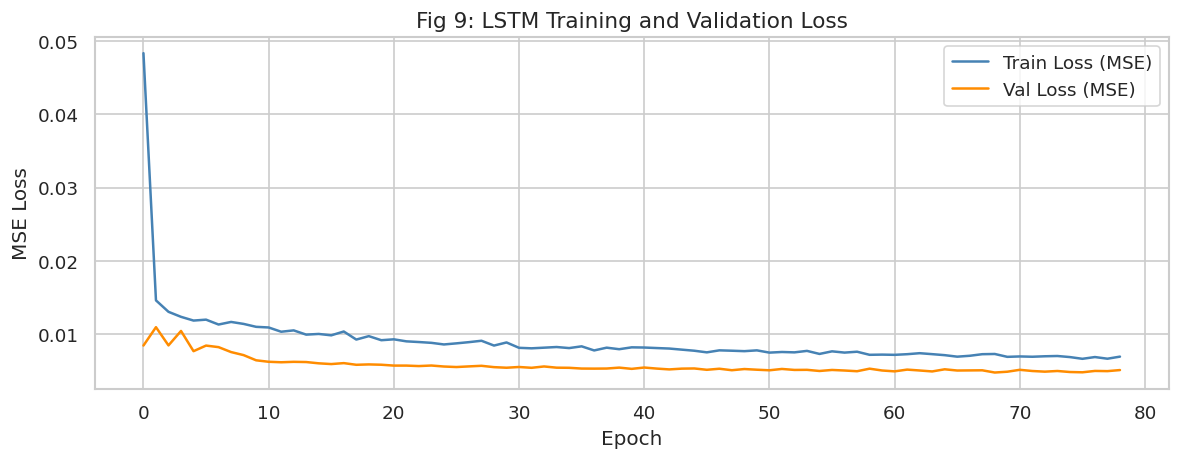

Saved: fig09_lstm_training_loss.png


In [25]:
# ── Training loss curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss (MSE)', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss (MSE)',   color='darkorange')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Fig 9: LSTM Training and Validation Loss', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig09_lstm_training_loss.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig09_lstm_training_loss.png")


In [26]:
# ── LSTM test predictions (inverse-transform) ────────────────────────────────
y_pred_lstm_sc = model_lstm.predict(X_test_seq, verbose=0).ravel()
y_pred_lstm    = scaler_y.inverse_transform(y_pred_lstm_sc.reshape(-1, 1)).ravel()

# Align y_test (skip first WINDOW_SIZE rows, same as sequences)
y_test_lstm = y_test[WINDOW_SIZE:]

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_test_lstm, y_pred_lstm)
r2_lstm   = r2_score(y_test_lstm, y_pred_lstm)

print("── LSTM — Test Set Metrics ───────────────────────────────────────────────")
print(f"  RMSE : {rmse_lstm:.4f} kW")
print(f"  MAE  : {mae_lstm:.4f} kW")
print(f"  R²   : {r2_lstm:.4f}")


── LSTM — Test Set Metrics ───────────────────────────────────────────────
  RMSE : 2218.5552 kW
  MAE  : 1238.4948 kW
  R²   : 0.9261


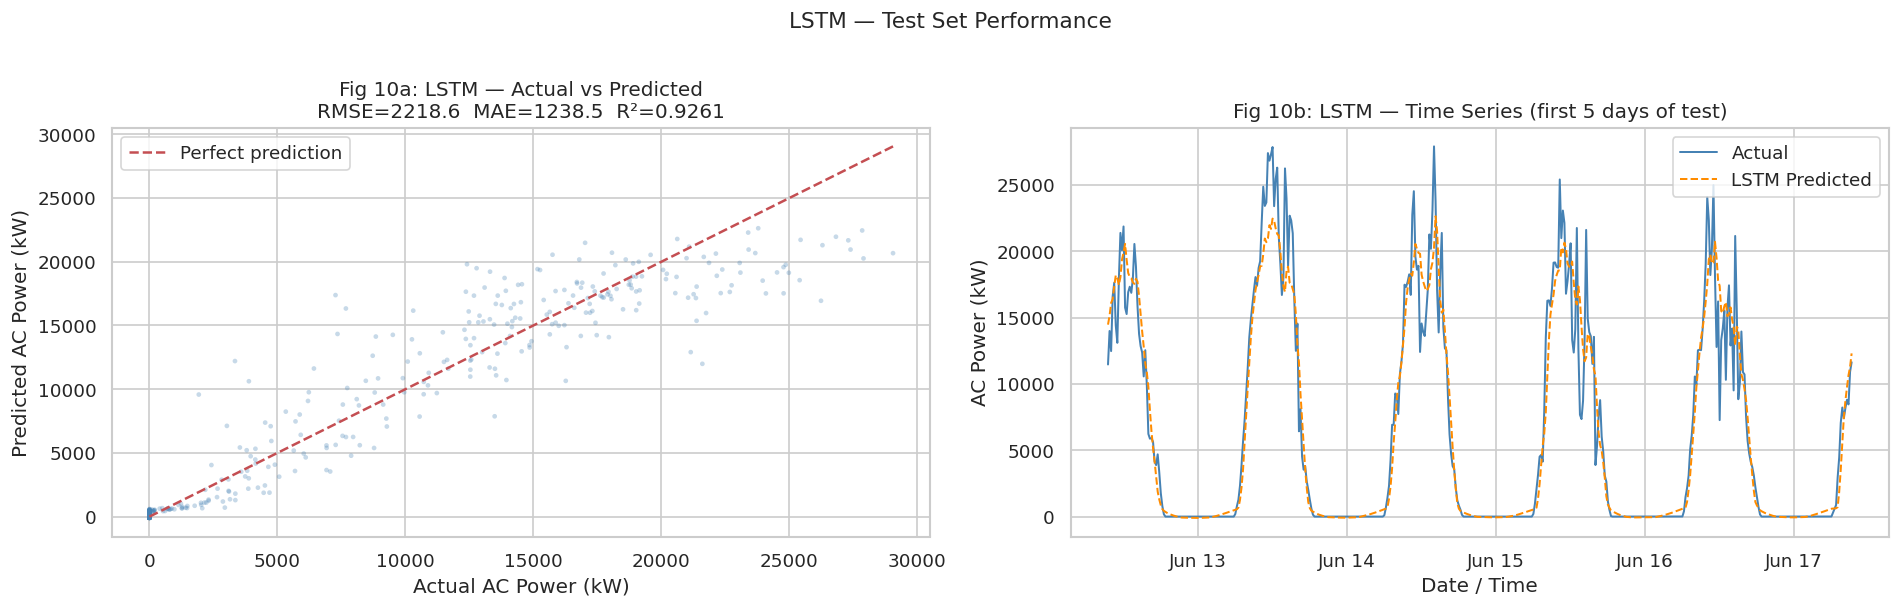

Saved: fig10_lstm_actual_vs_pred.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Scatter ───────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test_lstm, y_pred_lstm, alpha=0.3, s=8,
           color='steelblue', edgecolors='none')
max_val = max(y_test_lstm.max(), y_pred_lstm.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual AC Power (kW)', fontsize=12)
ax.set_ylabel('Predicted AC Power (kW)', fontsize=12)
ax.set_title(f'Fig 10a: LSTM — Actual vs Predicted\nRMSE={rmse_lstm:.1f}  MAE={mae_lstm:.1f}  R²={r2_lstm:.4f}',
             fontsize=12)
ax.legend()

# ── Time series ───────────────────────────────────────────────────────────────
ax = axes[1]
test_times_lstm = test_df['DATE_TIME'].values[WINDOW_SIZE:]
mask_5d = pd.to_datetime(test_times_lstm) < (pd.to_datetime(test_times_lstm[0]) + pd.Timedelta(days=5))
ax.plot(pd.to_datetime(test_times_lstm[mask_5d]), y_test_lstm[mask_5d],
        color='steelblue', linewidth=1.2, label='Actual')
ax.plot(pd.to_datetime(test_times_lstm[mask_5d]), y_pred_lstm[mask_5d],
        color='darkorange', linewidth=1.2, linestyle='--', label='LSTM Predicted')
ax.set_xlabel('Date / Time', fontsize=12)
ax.set_ylabel('AC Power (kW)', fontsize=12)
ax.set_title('Fig 10b: LSTM — Time Series (first 5 days of test)', fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('LSTM — Test Set Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig10_lstm_actual_vs_pred.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig10_lstm_actual_vs_pred.png")


## 9. Baseline Model
A **naïve mean predictor** (predicts the training-set mean for every sample)  
establishes the minimum bar any real model must beat.


In [28]:
# Baseline: predict training mean for all test samples
y_baseline = np.full_like(y_test, fill_value=y_train.mean())

rmse_base = np.sqrt(mean_squared_error(y_test, y_baseline))
mae_base  = mean_absolute_error(y_test, y_baseline)
r2_base   = r2_score(y_test, y_baseline)     # should be ≤ 0

print("── Baseline (Train Mean Predictor) — Test Set Metrics ────────────────────")
print(f"  RMSE : {rmse_base:.4f} kW")
print(f"  MAE  : {mae_base:.4f} kW")
print(f"  R²   : {r2_base:.4f}")
print()
print(f"Training-set mean: {y_train.mean():.2f} kW")
print("(R² ≤ 0 confirms this model has no predictive power beyond the mean.)")


── Baseline (Train Mean Predictor) — Test Set Metrics ────────────────────
  RMSE : 7983.7004 kW
  MAE  : 7122.6750 kW
  R²   : -0.0044

Training-set mean: 6810.56 kW
(R² ≤ 0 confirms this model has no predictive power beyond the mean.)


## 10. Model Comparison Table
All models evaluated on the **same held-out test set** using consistent metrics:
RMSE (lower = better), MAE (lower = better), R² (higher = better, max 1.0).


In [29]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline (Train Mean)',
        'Random Forest (GridSearchCV)',
        'LSTM'
    ],
    'RMSE (kW)': [
        round(rmse_base, 2),
        round(rmse_rf,   2),
        round(rmse_lstm, 2)
    ],
    'MAE (kW)': [
        round(mae_base, 2),
        round(mae_rf,   2),
        round(mae_lstm, 2)
    ],
    'R²': [
        round(r2_base, 4),
        round(r2_rf,   4),
        round(r2_lstm, 4)
    ],
})

# Mark the best (lowest RMSE) model
best_idx = comparison['RMSE (kW)'].idxmin()
comparison[''] = ['', '', '']
comparison.loc[best_idx, ''] = '← BEST'

print("=" * 65)
print("MODEL COMPARISON — Test Set (same 20% held-out period)")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)
print(f"\nBest model: {comparison.loc[best_idx, 'Model']}")
print(f"  RMSE improvement over baseline: "
      f"{rmse_base - comparison.loc[best_idx, 'RMSE (kW)']:.2f} kW "
      f"({100*(rmse_base - comparison.loc[best_idx, 'RMSE (kW)'])/rmse_base:.1f}% reduction)")


MODEL COMPARISON — Test Set (same 20% held-out period)
                       Model  RMSE (kW)  MAE (kW)      R²       
       Baseline (Train Mean)    7983.70   7122.67 -0.0044       
Random Forest (GridSearchCV)     521.45    245.88  0.9957 ← BEST
                        LSTM    2218.56   1238.49  0.9261       

Best model: Random Forest (GridSearchCV)
  RMSE improvement over baseline: 7462.25 kW (93.5% reduction)


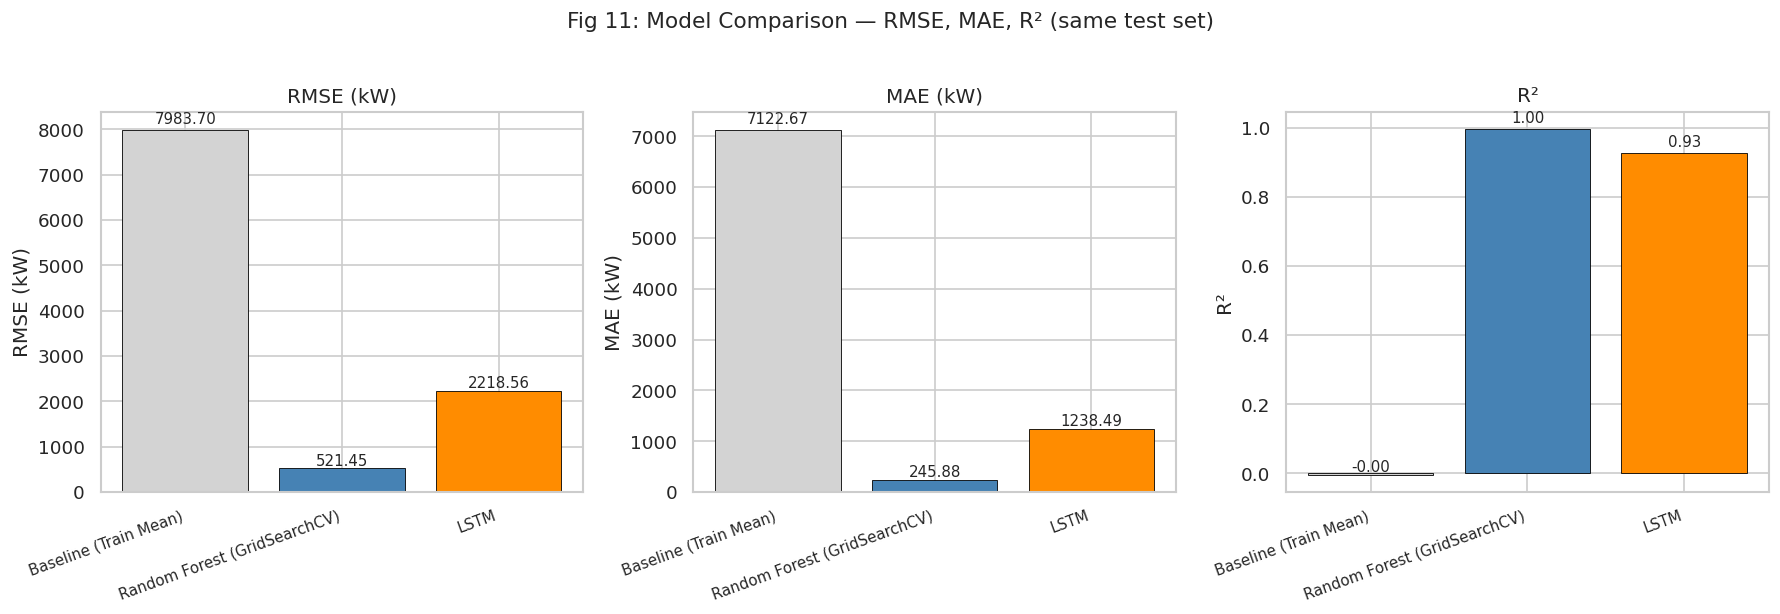

Saved: fig11_model_comparison.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = comparison['Model'].values
colors = ['lightgrey', 'steelblue', 'darkorange']

for ax, metric in zip(axes, ['RMSE (kW)', 'MAE (kW)', 'R²']):
    vals = comparison[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Fig 11: Model Comparison — RMSE, MAE, R² (same test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig11_model_comparison.png")


## 11. Generalisation Check — Plant 2
To test whether the best model generalises across plants, we apply the  
Random Forest (trained on Plant 1 train set) to the Plant 2 test set.  
This is a cross-plant zero-shot evaluation.


In [31]:
df_p2 = plant2[['DATE_TIME'] + FEATURES + [TARGET]].copy()
df_p2.sort_values('DATE_TIME', inplace=True)
df_p2.reset_index(drop=True, inplace=True)

split_p2 = int(len(df_p2) * 0.80)
X_p2_test = df_p2.iloc[split_p2:][FEATURES].values
y_p2_test = df_p2.iloc[split_p2:][TARGET].values

y_pred_p2_rf = rf_best.predict(X_p2_test)

rmse_p2 = np.sqrt(mean_squared_error(y_p2_test, y_pred_p2_rf))
mae_p2  = mean_absolute_error(y_p2_test, y_pred_p2_rf)
r2_p2   = r2_score(y_p2_test, y_pred_p2_rf)

print("── RF Generalisation — Plant 2 Test Set ─────────────────────────────────")
print(f"  RMSE : {rmse_p2:.4f} kW")
print(f"  MAE  : {mae_p2:.4f} kW")
print(f"  R²   : {r2_p2:.4f}")
print()
print("Comparison: Plant 1 test → Plant 2 test")
print(f"  RMSE delta: {rmse_p2 - rmse_rf:+.2f} kW")
print(f"  R²   delta: {r2_p2 - r2_rf:+.4f}")


── RF Generalisation — Plant 2 Test Set ─────────────────────────────────
  RMSE : 2834.8024 kW
  MAE  : 1020.5555 kW
  R²   : 0.7359

Comparison: Plant 1 test → Plant 2 test
  RMSE delta: +2313.36 kW
  R²   delta: -0.2598


## 12. Save Results for Report Verification

In [32]:
# Save metrics CSV — every number in the report comes from this file
metrics_df = pd.DataFrame({
    'Model': ['Baseline', 'Random Forest (Plant1 test)', 'LSTM (Plant1 test)',
              'RF Generalisation (Plant2 test)'],
    'RMSE_kW': [rmse_base, rmse_rf, rmse_lstm, rmse_p2],
    'MAE_kW':  [mae_base,  mae_rf,  mae_lstm,  mae_p2],
    'R2':      [r2_base,   r2_rf,   r2_lstm,   r2_p2],
})
metrics_df.to_csv('model_metrics.csv', index=False)
print("Saved: model_metrics.csv")
print()
print(metrics_df.round(4).to_string(index=False))

# Save best RF params
import json as _json
best_params = grid_search.best_params_
with open('rf_best_params.json', 'w') as f:
    _json.dump(best_params, f, indent=2)
print("\nSaved: rf_best_params.json")
print("Best RF params:", best_params)


Saved: model_metrics.csv

                          Model   RMSE_kW    MAE_kW      R2
                       Baseline 7983.7004 7122.6750 -0.0044
    Random Forest (Plant1 test)  521.4469  245.8797  0.9957
             LSTM (Plant1 test) 2218.5552 1238.4948  0.9261
RF Generalisation (Plant2 test) 2834.8024 1020.5555  0.7359

Saved: rf_best_params.json
Best RF params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
